In [1]:
import numpy as np
from numpy.linalg import norm
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURATION: ALL PARAMETERS DEFINED HERE
# ============================================================

# --- Physical Constants ---
G = 6.67430e-20  # km^3 / (kg s^2)
M_SUN   = 1.98847e30   # kg
M_JUP   = 1.898e27     # kg
R_JUP   = 71492.0      # km
AU_KM   = 1.495978707e8  # km

# --- Numerical Integration Tolerances ---
RTOL = 1e-10
ATOL = 1e-10

# ============================================================
# ACTIVE SYSTEM CONFIGURATION (Change this to switch systems)
# ============================================================

# Kepler-432 system (K0V star, hot Jupiter, a ≈ 0.0896 AU, P ≈ 52.5 d)
M_STAR = 1.19 * M_SUN
M_PLANET = 5.2 * M_JUP
R_PLANET = 1.155 * R_JUP
A_PLANET_AU = 0.0896
A_PLANET_KM = A_PLANET_AU * AU_KM
SYSTEM_NAME = "Kepler-432"

# Alternative: TOI-1431 system (commented out)
# M_STAR = 1.9 * M_SUN
# M_PLANET = 3.12 * M_JUP
# R_PLANET = 1.49 * R_JUP
# A_PLANET_AU = 0.047
# A_PLANET_KM = A_PLANET_AU * AU_KM
# SYSTEM_NAME = "TOI-1431"

# ============================================================
# SLINGSHOT ANALYSIS PARAMETERS
# ============================================================

# Distance factors for "asymptotic" regime (planet frame)
R_FAR_FACTOR = 20  # satellite must be > R_far_factor * R_planet to be "far"
MIN_CLEARANCE_FACTOR = 1.05  # reject if closer than this multiple of R_planet

# Initial satellite sampling parameters (relative to planet)
SAT_R_MIN_FACTOR = 20  # minimum radius (in planet radii)
SAT_R_MAX_FACTOR = 5 * (A_PLANET_KM / R_PLANET)  # maximum radius
SAT_V_REL_MIN = 12  # km/s, minimum relative velocity
SAT_V_REL_MAX = 80.0  # km/s, maximum relative velocity

# ============================================================
# 1. HOT-JUPITER BARYCENTRIC INITIAL CONDITIONS
# ============================================================

def init_hot_jupiter_barycentric(
    a_km=None,
    m_star=None,
    m_p=None,
    phase=0.0,
    prograde=True,
):
    """
    Return barycentric initial conditions for a star+planet 2-body system
    on (approximately) circular orbit of radius a_km.
    
    If parameters are None, uses global system configuration.

    State vector:
      Y_sp = [xs, ys, vxs, vys,  xp, yp, vxp, vyp]
    """
    if a_km is None:
        a_km = A_PLANET_KM
    if m_star is None:
        m_star = M_STAR
    if m_p is None:
        m_p = M_PLANET
    
    M_tot = m_star + m_p
    mu_tot = G * M_tot

    r = a_km
    v_rel = np.sqrt(mu_tot / r)  # relative orbital speed |v_p - v_s|

    # Relative position (planet wrt star) at given phase
    x_rel = r * np.cos(phase)
    y_rel = r * np.sin(phase)

    # Relative velocity (planet wrt star), 90 deg ahead for circular orbit
    sign = 1.0 if prograde else -1.0
    vx_rel = -sign * v_rel * np.sin(phase)
    vy_rel =  sign * v_rel * np.cos(phase)

    # Barycentric factors
    f_star = m_p / M_tot   # |r_star| = f_star * r
    f_plan = m_star / M_tot

    xs  = -f_star * x_rel
    ys  = -f_star * y_rel
    xp  =  f_plan * x_rel
    yp  =  f_plan * y_rel

    vxs = -f_star * vx_rel
    vys = -f_star * vy_rel
    vxp =  f_plan * vx_rel
    vyp =  f_plan * vy_rel

    return np.array([xs, ys, vxs, vys, xp, yp, vxp, vyp], dtype=float)

# ============================================================
# 2. RESTRICTED 3-BODY ODE: STAR + HOT JUPITER + MASSLESS SATELLITE
# ============================================================

def restricted_3body_ode(t, Y, m_star, m_p):
    """
    Restricted planar 3-body problem:
      body 1: star   (mass m_star)
      body 2: planet (mass m_p)
      body 3: satellite (mass ~0, feels both but does not back-react)

    Y = [
      xs, ys, vxs, vys,
      xp, yp, vxp, vyp,
      x3, y3, vx3, vy3
    ]
    """
    xs, ys, vxs, vys, xp, yp, vxp, vyp, x3, y3, vx3, vy3 = Y

    # Star-planet separation
    dx_sp = xp - xs
    dy_sp = yp - ys
    r_sp2 = dx_sp*dx_sp + dy_sp*dy_sp
    r_sp  = np.sqrt(r_sp2)
    r_sp3 = r_sp2 * r_sp if r_sp > 0 else np.inf

    # Satellite-star separation (vector from sat -> star)
    dx_3s = xs - x3
    dy_3s = ys - y3
    r_3s2 = dx_3s*dx_3s + dy_3s*dy_3s
    r_3s  = np.sqrt(r_3s2)
    r_3s3 = r_3s2 * r_3s if r_3s > 0 else np.inf

    # Satellite-planet separation (vector from sat -> planet)
    dx_3p = xp - x3
    dy_3p = yp - y3
    r_3p2 = dx_3p*dx_3p + dy_3p*dy_3p
    r_3p  = np.sqrt(r_3p2)
    r_3p3 = r_3p2 * r_3p if r_3p > 0 else np.inf

    # Accelerations of star and planet (only due to each other)
    ax_s = G * m_p * dx_sp / r_sp3
    ay_s = G * m_p * dy_sp / r_sp3
    ax_p = -G * m_star * dx_sp / r_sp3
    ay_p = -G * m_star * dy_sp / r_sp3

    # Satellite acceleration from star and planet
    ax_3 = G * (m_star * dx_3s / r_3s3 + m_p * dx_3p / r_3p3)
    ay_3 = G * (m_star * dy_3s / r_3s3 + m_p * dy_3p / r_3p3)

    return np.array([
        vxs, vys, ax_s, ay_s,
        vxp, vyp, ax_p, ay_p,
        vx3, vy3, ax_3, ay_3,
    ], dtype=float)

def simulate_3body(
    Y0,
    t_span,
    m_star=None,
    m_p=None,
    n_eval=None,
):
    """
    Integrate the restricted 3-body system (no collision events for now).
    Uses global M_STAR and M_PLANET if not provided.
    """
    if m_star is None:
        m_star = M_STAR
    if m_p is None:
        m_p = M_PLANET
    
    if n_eval is not None:
        t_eval = np.linspace(t_span[0], t_span[1], n_eval)
    else:
        t_eval = None

    try:
        sol = solve_ivp(
            restricted_3body_ode,
            t_span,
            Y0,
            args=(m_star, m_p),
            rtol=RTOL,
            atol=ATOL,
            dense_output=False,
            t_eval=t_eval,
        )
    except Exception as e:
        print("Integration failed:", e)
        return None

    if not sol.success:
        print("Integration unsuccessful:", sol.message)
        return None

    return sol


In [2]:
def wrap_angle_deg(d):
    while d > 180.0:
        d -= 360.0
    while d < -180.0:
        d += 360.0
    return d

def analyze_3body_hyperbolic_barycentric(
    sol,
    m_star=None,
    m_p=None,
    R_p=None,
    r_far_factor=None,
    min_clearance_factor=None,
):
    """
    Analyze a single 3-body trajectory in the *barycentric frame*.
    Designed for hyperbolic encounter analysis with impact parameters and deflection angles.
    Uses global parameters if not provided.

    - requires satellite to start and end 'far' from barycenter (r > r_far_factor * scale)
    - rejects trajectories that come closer than R_p * min_clearance_factor to planet

    Returns dict with:
      - v_i_bary, v_f_bary   : initial/final barycentric speeds (km/s)
      - delta_v_bary         : v_f_bary - v_i_bary (energy gain in barycentric frame)
      - deflection_bary      : angle between initial and final barycentric velocity (deg)
      - r_min                : minimum planet-satellite separation (km)
      - impact_parameter     : approximate impact parameter wrt barycenter (km)
      - v_infinity_bary      : asymptotic speed magnitude in barycentric frame
    """
    if m_star is None:
        m_star = M_STAR
    if m_p is None:
        m_p = M_PLANET
    if R_p is None:
        R_p = R_PLANET
    if r_far_factor is None:
        r_far_factor = R_FAR_FACTOR
    if min_clearance_factor is None:
        min_clearance_factor = MIN_CLEARANCE_FACTOR
    
    if sol is None or sol.y.shape[1] < 2:
        return None

    y = sol.y

    # indices: 0,1,2,3 = star; 4,5,6,7 = planet; 8,9,10,11 = satellite
    xsat = y[8]
    ysat = y[9]
    vxsat = y[10]
    vysat = y[11]

    # Barycentric position and velocity of satellite
    r_bary = np.hypot(xsat, ysat)  # distance from barycenter

    # Closest approach to planet
    xp = y[4]
    yp = y[5]
    dx = xsat - xp
    dy = ysat - yp
    r_to_planet = np.hypot(dx, dy)
    k_min = np.argmin(r_to_planet)
    r_min = r_to_planet[k_min]

    if r_min <= R_p * min_clearance_factor:
        # Grazing or collision -> reject
        return None

    # Find asymptotic regions: far from barycenter
    r_far = np.max(r_bary) * 0.5  # Use half max distance as "far"
    far_idx = np.where(r_bary > r_far)[0]
    if far_idx.size < 2:
        # Not enough asymptotic data
        return None

    i0 = far_idx[0]   # start: satellite is far
    i1 = far_idx[-1]  # end: satellite is far

    # Barycentric velocities at start & end
    vx_i_bary = vxsat[i0]
    vy_i_bary = vysat[i0]
    vx_f_bary = vxsat[i1]
    vy_f_bary = vysat[i1]

    v_i_bary = np.hypot(vx_i_bary, vy_i_bary)
    v_f_bary = np.hypot(vx_f_bary, vy_f_bary)

    if v_i_bary == 0.0 or v_f_bary == 0.0:
        return None

    # Deflection angle in barycentric frame
    theta_i_bary = np.degrees(np.arctan2(vy_i_bary, vx_i_bary))
    theta_f_bary = np.degrees(np.arctan2(vy_f_bary, vx_f_bary))
    deflection_bary = wrap_angle_deg(theta_f_bary - theta_i_bary)

    # Approximate impact parameter: L / v_i_bary, where L is specific angular momentum
    pos_i_bary = np.array([xsat[i0], ysat[i0]])
    vel_i_bary = np.array([vx_i_bary, vy_i_bary])
    L_mag = np.abs(np.cross(pos_i_bary, vel_i_bary))  # |r × v|
    impact_parameter = L_mag / v_i_bary if v_i_bary > 0 else 0.0

    # Compute specific orbital energy in the barycentric frame (includes both star & planet potentials)
    # At the chosen asymptotic indices compute distances to star and planet
    # Note: potential = -G*(m_star/r_3s + m_p/r_3p)
    # Specific energy: eps = 0.5*v^2 + potential
    # Use positions/velocities at i0 (start) and i1 (end)
    # Satellite-star vector at i0/i1
    xs = y[0]
    ys = y[1]
    xp = y[4]
    yp = y[5]

    # distances from satellite to star/planet at start (i0)
    dx_3s_i = xs[i0] - xsat[i0]
    dy_3s_i = ys[i0] - ysat[i0]
    r_3s_i = np.hypot(dx_3s_i, dy_3s_i)

    dx_3p_i = xp[i0] - xsat[i0]
    dy_3p_i = yp[i0] - ysat[i0]
    r_3p_i = np.hypot(dx_3p_i, dy_3p_i)

    # distances from satellite to star/planet at end (i1)
    dx_3s_f = xs[i1] - xsat[i1]
    dy_3s_f = ys[i1] - ysat[i1]
    r_3s_f = np.hypot(dx_3s_f, dy_3s_f)

    dx_3p_f = xp[i1] - xsat[i1]
    dy_3p_f = yp[i1] - ysat[i1]
    r_3p_f = np.hypot(dx_3p_f, dy_3p_f)

    # Avoid division by zero
    pot_i = 0.0
    pot_f = 0.0
    if r_3s_i > 0:
        pot_i += -G * m_star / r_3s_i
    if r_3p_i > 0:
        pot_i += -G * m_p / r_3p_i
    if r_3s_f > 0:
        pot_f += -G * m_star / r_3s_f
    if r_3p_f > 0:
        pot_f += -G * m_p / r_3p_f

    eps_i_bary = 0.5 * (vx_i_bary**2 + vy_i_bary**2) + pot_i
    eps_f_bary = 0.5 * (vx_f_bary**2 + vy_f_bary**2) + pot_f
    unbound_bary = bool(eps_f_bary > 0.0)
    unbound_i_bary = bool(eps_i_bary > 0.0)

    return {
        "v_i_bary": v_i_bary,
        "v_f_bary": v_f_bary,
        "delta_v_bary": v_f_bary - v_i_bary,
        "deflection_bary": deflection_bary,
        "r_min": r_min,
        "impact_parameter": impact_parameter,
        "frac_of_180_bary": deflection_bary / 180.0,
        "eps_i_bary": eps_i_bary,
        "eps_f_bary": eps_f_bary,
        "unbound_bary": unbound_bary,
        "unbound_i_bary": unbound_i_bary,
        "unbound_i_bary": unbound_i_bary,
    }

def analyze_3body_slingshot(
    sol,
    m_p=None,
    R_p=None,
    r_far_factor=None,
    min_clearance_factor=None,
):
    """
    Analyze a single 3-body trajectory in the *planet frame*.
    Uses global parameters if not provided.

    - requires satellite to start and end 'far' from planet (r > R_p * r_far_factor)
    - rejects trajectories that come closer than R_p * min_clearance_factor

    Returns dict with:
      - v_i, v_f       : initial/final planet-frame speeds (km/s)
      - delta_v        : v_f - v_i
      - deflection     : angle between initial and final planet-frame velocity (deg)
      - r_min          : minimum planet-satellite separation (km)
      - eps_i, eps_f   : specific orbital energy wrt planet at start/end
      - unbound_f      : bool, final state unbound wrt planet
      - frac_of_180    : deflection / 180° (for comparison to 2-body limit)
    """
    if m_p is None:
        m_p = M_PLANET
    if R_p is None:
        R_p = R_PLANET
    if r_far_factor is None:
        r_far_factor = R_FAR_FACTOR
    if min_clearance_factor is None:
        min_clearance_factor = MIN_CLEARANCE_FACTOR
    
    if sol is None or sol.y.shape[1] < 2:
        return None

    y = sol.y

    # indices: 4,5,6,7 = planet; 8,9,10,11 = satellite
    xp = y[4]
    yp = y[5]
    vxp = y[6]
    vyp = y[7]

    xsat = y[8]
    ysat = y[9]
    vxsat = y[10]
    vysat = y[11]

    dx = xsat - xp
    dy = ysat - yp
    r = np.hypot(dx, dy)

    # Closest approach
    k_min = np.argmin(r)
    r_min = r[k_min]

    if r_min <= R_p * min_clearance_factor:
        # Grazing or collision -> reject
        return None

    # Indices where satellite is "far" from planet
    r_far = R_p * r_far_factor
    far_idx = np.where(r > r_far)[0]
    if far_idx.size < 2:
        # Never really asymptotic
        return None

    i0 = far_idx[0]
    i1 = far_idx[-1]

    # Planet-frame velocities at start & end
    dvx_i = vxsat[i0] - vxp[i0]
    dvy_i = vysat[i0] - vyp[i0]
    dvx_f = vxsat[i1] - vxp[i1]
    dvy_f = vysat[i1] - vyp[i1]

    v_i = np.hypot(dvx_i, dvy_i)
    v_f = np.hypot(dvx_f, dvy_f)

    if v_i == 0.0 or v_f == 0.0:
        return None

    # Deflection angle in planet frame
    theta_i = np.degrees(np.arctan2(dvy_i, dvx_i))
    theta_f = np.degrees(np.arctan2(dvy_f, dvx_f))
    deflection = wrap_angle_deg(theta_f - theta_i)

    mu_p = G * m_p
    r_i = r[i0]
    r_f = r[i1]

    eps_i = 0.5 * (dvx_i**2 + dvy_i**2) - mu_p / r_i
    eps_f = 0.5 * (dvx_f**2 + dvy_f**2) - mu_p / r_f
    unbound_f = eps_f > 0.0

    return {
        "v_i": v_i,
        "v_f": v_f,
        "delta_v": v_f - v_i,
        "deflection": deflection,
        "r_min": r_min,
        "eps_i": eps_i,
        "eps_f": eps_f,
        "unbound_f": unbound_f,
        "frac_of_180": deflection / 180.0,
    }


In [3]:
def sample_satellite_state_barycentric(
    Y_sp0,
    N=1,
    v_mag_min=None,
    v_mag_max=None,
    impact_param_min=None,
    impact_param_max=None,
    angle_in_min=-180.0,
    angle_in_max=180.0,
    rng=None,
):
    """
    Sample N satellite initial states in the barycentric frame using parametric controls:
      - Velocity magnitude: v_i ∈ [v_mag_min, v_mag_max]
      - Impact parameter: b ∈ [impact_param_min, impact_param_max]
      - Incoming angle: θ_in ∈ [angle_in_min, angle_in_max]
    
    Y_sp0: star+planet barycentric state [xs,ys,vxs,vys,xp,yp,vxp,vyp]
    Returns array of shape (N, 4): [x3,y3,vx3,vy3] in barycentric frame.

    Strategy:
      - Place satellite at distance r_init far from barycenter along incoming trajectory
      - Compute r_init from impact parameter and incoming angle
      - Give satellite velocity magnitude v_mag at angle θ_in toward barycenter
    """
    if v_mag_min is None:
        v_mag_min = 15.0
    if v_mag_max is None:
        v_mag_max = 70.0
    if impact_param_min is None:
        impact_param_min = R_PLANET * 10
    if impact_param_max is None:
        impact_param_max = R_PLANET * 100
    if rng is None:
        rng = np.random.default_rng()

    x3_list = []
    y3_list = []
    vx3_list = []
    vy3_list = []

    for _ in range(N):
        # Sample independent variables
        v_mag = rng.uniform(v_mag_min, v_mag_max)
        impact_param = rng.uniform(impact_param_min, impact_param_max)
        angle_in_deg = rng.uniform(angle_in_min, angle_in_max)  # incoming angle (deg)
        angle_in_rad = np.radians(angle_in_deg)
        
        # Azimuthal angle for where satellite enters the system
        azimuth = rng.uniform(0.0, 2.0 * np.pi)

        # Compute incoming trajectory geometry:
        # Hyperbola with impact parameter b and incoming velocity v_mag
        # Distance at "infinity": r_init large; closest approach: r_min ~ impact_param
        # For a hyperbola, r_init ~ 10 * impact_param is a reasonable asymptotic distance
        r_init = 10.0 * impact_param

        # Position at asymptote in local frame (impact parameter frame)
        # Local frame: x = radial inward, y = impact parameter direction
        x_local = -r_init  # approaching from negative side
        y_local = impact_param  # offset by impact parameter

        # Velocity in local frame: magnitude v_mag, directed toward origin
        # Angle_in controls the tangential vs radial mix
        vx_local = v_mag * np.cos(angle_in_rad)  # radial component (toward origin)
        vy_local = v_mag * np.sin(angle_in_rad)  # tangential component

        # Rotate local frame to barycentric frame using azimuth
        cos_az = np.cos(azimuth)
        sin_az = np.sin(azimuth)
        x3 = x_local * cos_az - y_local * sin_az
        y3 = x_local * sin_az + y_local * cos_az
        vx3 = vx_local * cos_az - vy_local * sin_az
        vy3 = vx_local * sin_az + vy_local * cos_az

        x3_list.append(x3)
        y3_list.append(y3)
        vx3_list.append(vx3)
        vy3_list.append(vy3)

    return np.column_stack([x3_list, y3_list, vx3_list, vy3_list])

def sample_satellite_state_near_planet(
    Y_sp0,
    N=1,
    R_p=None,
    r_min_factor=None,
    r_max_factor=None,
    v_rel_min=None,
    v_rel_max=None,
    rng=None,
):
    """
    Sample N satellite initial states around the planet at t=0.
    Uses global SAT_* parameters if not provided.

    Y_sp0: star+planet barycentric state [xs,ys,vxs,vys,xp,yp,vxp,vyp]
    Returns array of shape (N, 4): [x3,y3,vx3,vy3] in barycentric frame.

    Strategy:
      - Place satellite at radius r0 in [r_min_factor*R_p, r_max_factor*R_p]
        around the planet at random angle θ.
      - Give it a velocity that is (mostly) inward toward the planet,
        with some azimuthal component, plus the planet's own velocity.
    """
    if R_p is None:
        R_p = R_PLANET
    if r_min_factor is None:
        r_min_factor = SAT_R_MIN_FACTOR
    if r_max_factor is None:
        r_max_factor = SAT_R_MAX_FACTOR
    if v_rel_min is None:
        v_rel_min = SAT_V_REL_MIN
    if v_rel_max is None:
        v_rel_max = SAT_V_REL_MAX
    if rng is None:
        rng = np.random.default_rng()

    xs, ys, vxs, vys, xp, yp, vxp, vyp = Y_sp0

    x3_list = []
    y3_list = []
    vx3_list = []
    vy3_list = []

    for _ in range(N):
        # Radius from planet
        r0 = R_p * rng.uniform(r_min_factor, r_max_factor)
        theta = rng.uniform(0.0, 2.0 * np.pi)

        # Position relative to planet
        ex = np.cos(theta)
        ey = np.sin(theta)

        x3 = xp + r0 * ex
        y3 = yp + r0 * ey

        # Velocity relative to planet
        v_rel_mag = rng.uniform(v_rel_min, v_rel_max)

        # Direction: mostly inward (toward planet = -e_r) with some tangential component
        alpha = rng.uniform(-np.pi/4.0, np.pi/4.0)  # spread around purely radial
        # radial inward and tangential basis
        er_in = -np.array([ex, ey])
        et    = np.array([-ey, ex])  # 90 deg CCW from ex,ey

        dir_vec = np.cos(alpha) * er_in + np.sin(alpha) * et
        dir_vec /= norm(dir_vec)

        v_rel = v_rel_mag * dir_vec

        vx3 = vxp + v_rel[0]
        vy3 = vyp + v_rel[1]

        x3_list.append(x3)
        y3_list.append(y3)
        vx3_list.append(vx3)
        vy3_list.append(vy3)

    return np.column_stack([x3_list, y3_list, vx3_list, vy3_list])

def evaluate_particle_3body(
    Y_sp0,
    sat_state,
    t_span=(0.0, 2.5e5),
    m_star=None,
    m_p=None,
    **ana_kwargs,
):
    """
    Build full Y0 = [star, planet, satellite], integrate, analyze.
    Uses global M_STAR and M_PLANET if not provided.

    Returns dict:
      {
        "ok": bool,
        "reason": str (if not ok),
        "analysis": dict (if ok),
      }
    """
    if m_star is None:
        m_star = M_STAR
    if m_p is None:
        m_p = M_PLANET
    
    xs, ys, vxs, vys, xp, yp, vxp, vyp = Y_sp0
    x3, y3, vx3, vy3 = sat_state

    Y0 = np.array([xs, ys, vxs, vys, xp, yp, vxp, vyp, x3, y3, vx3, vy3], dtype=float)

    sol = simulate_3body(Y0, t_span, m_star=m_star, m_p=m_p, n_eval=None)
    if sol is None:
        return {"ok": False, "reason": "integration_failed"}

    ana = analyze_3body_slingshot(sol, m_p=m_p, **ana_kwargs)
    if ana is None:
        return {"ok": False, "reason": "geometry_or_energy_failed"}

    # We want final state unbound wrt planet and positive Δv
    if not ana["unbound_f"]:
        return {"ok": False, "reason": "bound_final"}
    if ana["delta_v"] <= 0.0:
        return {"ok": False, "reason": "no_gain"}

    return {"ok": True, "reason": "", "analysis": ana, "sol": sol, "Y0": Y0}

def run_batch_mc_3body(
    N=2000,
    t_span=(0.0, 2.5e5),
    m_star=None,
    m_p=None,
    rng=None,
    r_min_factor=None,
    r_max_factor=None,
    v_rel_min=None,
    v_rel_max=None,
    **ana_kwargs,
):
    """
    Monte Carlo over satellite initial conditions in the restricted 3-body system.
    Uses planet-frame sampling and planet-frame analysis.
    Uses global system parameters if not provided.

    Returns dict:
      {
        "Y_sp0": Y_sp0 (star+planet state at t=0),
        "sat_states": sat_states (N x 4),
        "ok": bool array,
        "delta_v": float array,
        "deflection": float array,
        "frac_of_180": float array,
        "r_min": float array,
        "results": list of per-particle dicts,
      }
    """
    if m_star is None:
        m_star = M_STAR
    if m_p is None:
        m_p = M_PLANET
    if rng is None:
        rng = np.random.default_rng()

    # Fixed star+planet system
    Y_sp0 = init_hot_jupiter_barycentric(m_star=m_star, m_p=m_p)

    sat_states = sample_satellite_state_near_planet(
        Y_sp0,
        N=N,
        r_min_factor=r_min_factor,
        r_max_factor=r_max_factor,
        v_rel_min=v_rel_min,
        v_rel_max=v_rel_max,
        rng=rng,
    )

    ok = np.zeros(N, dtype=bool)
    delta_v = np.zeros(N)
    deflection = np.zeros(N)
    frac_of_180 = np.zeros(N)
    r_min = np.zeros(N)

    results = []

    for i in range(N):
        res = evaluate_particle_3body(
            Y_sp0, sat_states[i], t_span=t_span, m_star=m_star, m_p=m_p, **ana_kwargs
        )
        results.append(res)

        if res.get("ok", False):
            ok[i] = True
            ana = res["analysis"]
            delta_v[i] = ana["delta_v"]
            deflection[i] = ana["deflection"]
            frac_of_180[i] = ana["frac_of_180"]
            r_min[i] = ana["r_min"]

    return {
        "Y_sp0": Y_sp0,
        "sat_states": sat_states,
        "ok": ok,
        "delta_v": delta_v,
        "deflection": deflection,
        "frac_of_180": frac_of_180,
        "r_min": r_min,
        "results": results,
    }

def run_batch_mc_3body_barycentric(
    N=2000,
    t_span=(0.0, 2.5e5),
    m_star=None,
    m_p=None,
    rng=None,
    v_mag_min=None,
    v_mag_max=None,
    impact_param_min=None,
    impact_param_max=None,
    angle_in_min=-180.0,
    angle_in_max=180.0,
    **ana_kwargs,
):
    """
    Monte Carlo over satellite initial conditions using barycentric parametric sampling.
    Analyzes using barycentric frame (hyperbolic encounter analysis).
    Uses global system parameters if not provided.

    Returns dict:
      {
        "Y_sp0": Y_sp0 (star+planet state at t=0),
        "sat_states": sat_states (N x 4),
        "ok": bool array,
        "delta_v_bary": float array (barycentric frame),
        "deflection_bary": float array (barycentric frame),
        "frac_of_180_bary": float array,
        "impact_parameter": float array,
        "r_min": float array,
        "results": list of per-particle dicts,
      }
    """
    if m_star is None:
        m_star = M_STAR
    if m_p is None:
        m_p = M_PLANET
    if rng is None:
        rng = np.random.default_rng()

    # Fixed star+planet system
    Y_sp0 = init_hot_jupiter_barycentric(m_star=m_star, m_p=m_p)

    sat_states = sample_satellite_state_barycentric(
        Y_sp0,
        N=N,
        v_mag_min=v_mag_min,
        v_mag_max=v_mag_max,
        impact_param_min=impact_param_min,
        impact_param_max=impact_param_max,
        angle_in_min=angle_in_min,
        angle_in_max=angle_in_max,
        rng=rng,
    )

    ok = np.zeros(N, dtype=bool)
    # Barycentric-frame metrics
    delta_v_bary = np.zeros(N)
    deflection_bary = np.zeros(N)
    frac_of_180_bary = np.zeros(N)
    impact_parameter = np.zeros(N)
    r_min = np.zeros(N)
    # barycentric asymptotic speeds
    v_i_bary = np.full(N, np.nan)
    v_f_bary = np.full(N, np.nan)
    # Barycentric energy metrics
    eps_i_bary = np.full(N, np.nan)
    eps_f_bary = np.full(N, np.nan)
    unbound_bary = np.zeros(N, dtype=bool)
    unbound_i_bary = np.zeros(N, dtype=bool)

    # Ensure planet-frame arrays exist as well so callers that expect
    # keys like 'delta_v' don't get a KeyError. Initialize with NaN.
    delta_v = np.full(N, np.nan)
    deflection = np.full(N, np.nan)
    frac_of_180 = np.full(N, np.nan)

    results = []

    for i in range(N):
        xs, ys, vxs, vys, xp, yp, vxp, vyp = Y_sp0
        x3, y3, vx3, vy3 = sat_states[i]

        Y0 = np.array([xs, ys, vxs, vys, xp, yp, vxp, vyp, x3, y3, vx3, vy3], dtype=float)

        sol = simulate_3body(Y0, t_span, m_star=m_star, m_p=m_p, n_eval=None)
        if sol is None:
            results.append({"ok": False, "reason": "integration_failed"})
            continue
        # Remove selection-only kwargs that the analyzer doesn't accept
        ana_kwargs_for_bary = dict(ana_kwargs)
        ana_kwargs_for_bary.pop("bary_unbound_requirement", None)
        ana_bary = analyze_3body_hyperbolic_barycentric(sol, m_star=m_star, m_p=m_p, **ana_kwargs_for_bary)
        if ana_bary is None:
            results.append({"ok": False, "reason": "geometry_or_energy_failed"})
            continue

        # Also compute planet-frame analysis so downstream code that expects
        # planet-frame keys like 'delta_v' continues to work.
        ana_planet = analyze_3body_slingshot(sol, m_p=m_p)

        # Accept if closest approach is safe (not a grazing collision)
        if ana_bary["r_min"] > R_PLANET * MIN_CLEARANCE_FACTOR:
            # Evaluate barycentric-unbound requirement if requested
            pass_bary = True
            # default: no barycentric requirement
            req = ana_kwargs.get("bary_unbound_requirement", None)
            # allow callers to pass requirement either via ana_kwargs or fall back to global
            if req is None:
                try:
                    req = BARY_UNBOUND_REQUIREMENT
                except NameError:
                    req = None

            if req is not None:
                eps_i_val = ana_bary.get("eps_i_bary", np.nan)
                eps_f_val = ana_bary.get("eps_f_bary", np.nan)
                pass_pre = False if np.isnan(eps_i_val) else (eps_i_val > 0)
                pass_post = False if np.isnan(eps_f_val) else (eps_f_val > 0)

                if req == 'pre':
                    pass_bary = pass_pre
                elif req == 'post':
                    pass_bary = pass_post
                elif req == 'either':
                    pass_bary = (pass_pre or pass_post)
                elif req == 'both':
                    pass_bary = (pass_pre and pass_post)
                else:
                    pass_bary = True

            if pass_bary:
                ok[i] = True
                # barycentric metrics
                delta_v_bary[i] = ana_bary.get("delta_v_bary", np.nan)
                deflection_bary[i] = ana_bary.get("deflection_bary", np.nan)
                frac_of_180_bary[i] = ana_bary.get("frac_of_180_bary", np.nan)
                impact_parameter[i] = ana_bary.get("impact_parameter", np.nan)
                r_min[i] = ana_bary.get("r_min", np.nan)
                # barycentric energy fields
                eps_i_bary[i] = ana_bary.get("eps_i_bary", np.nan)
                eps_f_bary[i] = ana_bary.get("eps_f_bary", np.nan)
                # barycentric asymptotic speeds
                v_i_bary[i] = ana_bary.get("v_i_bary", np.nan)
                v_f_bary[i] = ana_bary.get("v_f_bary", np.nan)
                # also store boolean pre/post unbound for convenience
                unbound_bary[i] = ana_bary.get("unbound_bary", False)
                unbound_i_bary[i] = ana_bary.get("unbound_i_bary", False)
                # planet-frame metrics (fill with NaN if unavailable)
                if ana_planet is not None:
                    # existing keys: v_i, v_f, delta_v, deflection, r_min, eps_i, eps_f, unbound_f
                    delta_v_val = ana_planet.get("delta_v", np.nan)
                    deflection_val = ana_planet.get("deflection", np.nan)
                    frac_val = ana_planet.get("frac_of_180", np.nan)
                else:
                    delta_v_val = np.nan
                    deflection_val = np.nan
                    frac_val = np.nan

                # store planet-frame metrics in arrays named as before
                delta_v[i] = delta_v_val
                deflection[i] = deflection_val
                frac_of_180[i] = frac_val

                results.append({
                    "ok": True,
                    "reason": "",
                    "analysis_bary": ana_bary,
                    "analysis_planet": ana_planet,
                    "sol": sol,
                    "Y0": Y0,
                })
            else:
                results.append({"ok": False, "reason": "barycentric_requirement_failed"})
        else:
            results.append({"ok": False, "reason": "collision"})

    return {
        "Y_sp0": Y_sp0,
        "sat_states": sat_states,
        "ok": ok,
        # barycentric-frame metrics
        "delta_v_bary": delta_v_bary,
        "deflection_bary": deflection_bary,
        "frac_of_180_bary": frac_of_180_bary,
        "impact_parameter": impact_parameter,
        "r_min": r_min,
        "eps_i_bary": eps_i_bary,
        "eps_f_bary": eps_f_bary,
        "v_i_bary": v_i_bary,
        "v_f_bary": v_f_bary,
        "unbound_bary": unbound_bary,
        "unbound_i_bary": unbound_i_bary,
        # planet-frame metrics (kept for compatibility with downstream code)
        "delta_v": delta_v,
        "deflection": deflection,
        "frac_of_180": frac_of_180,
        "results": results,
    }

def run_batch_mc_3body(
    N=2000,
    t_span=(0.0, 2.5e5),
    m_star=None,
    m_p=None,
    rng=None,
    r_min_factor=None,
    r_max_factor=None,
    v_rel_min=None,
    v_rel_max=None,
    **ana_kwargs,
):
    """
    Monte Carlo over satellite initial conditions in the restricted 3-body system.
    Uses global system parameters if not provided.

    Returns dict:
      {
        "Y_sp0": Y_sp0 (star+planet state at t=0),
        "sat_states": sat_states (N x 4),
        "ok": bool array,
        "delta_v": float array,
        "deflection": float array,
        "frac_of_180": float array,
        "r_min": float array,
        "results": list of per-particle dicts,
      }
    """
    if m_star is None:
        m_star = M_STAR
    if m_p is None:
        m_p = M_PLANET
    if rng is None:
        rng = np.random.default_rng()

    # Fixed star+planet system
    Y_sp0 = init_hot_jupiter_barycentric(m_star=m_star, m_p=m_p)

    sat_states = sample_satellite_state_near_planet(
        Y_sp0,
        N=N,
        r_min_factor=r_min_factor,
        r_max_factor=r_max_factor,
        v_rel_min=v_rel_min,
        v_rel_max=v_rel_max,
        rng=rng,
    )

    ok = np.zeros(N, dtype=bool)
    delta_v = np.zeros(N)
    deflection = np.zeros(N)
    frac_of_180 = np.zeros(N)
    r_min = np.zeros(N)

    results = []

    for i in range(N):
        res = evaluate_particle_3body(
            Y_sp0, sat_states[i], t_span=t_span, m_star=m_star, m_p=m_p, **ana_kwargs
        )
        results.append(res)

        if res.get("ok", False):
            ok[i] = True
            ana = res["analysis"]
            delta_v[i] = ana["delta_v"]
            deflection[i] = ana["deflection"]
            frac_of_180[i] = ana["frac_of_180"]
            r_min[i] = ana["r_min"]

    return {
        "Y_sp0": Y_sp0,
        "sat_states": sat_states,
        "ok": ok,
        "delta_v": delta_v,
        "deflection": deflection,
        "frac_of_180": frac_of_180,
        "r_min": r_min,
        "results": results,
    }



In [ ]:
def select_top_indices_by_delta_v(mc, top_frac=0.10, min_top=3):
    ok = mc["ok"]
    delta_v = mc["delta_v"]

    return select_top_indices_by_delta_v_with_bary(mc, top_frac=top_frac, min_top=min_top, bary_unbound_requirement=None)


def select_top_indices_by_delta_v_with_bary(mc, top_frac=0.10, min_top=3, bary_unbound_requirement=None, metric='planet_delta_v', sign='maximize'):
    """Select top indices using a flexible metric with optional barycentric-unbound filtering.

    bary_unbound_requirement: None|'pre'|'post'|'either'|'both'
    metric: 'planet_delta_v'|'bary_delta_v'|'bary_delta_v_pct'|'bary_delta_v_abs'
    sign: 'maximize'|'minimize'|'abs' (how to rank the metric)
    """
    ok = mc.get("ok", None)
    if ok is None:
        return np.array([], dtype=int)

    delta_v = mc.get("delta_v", None)
    if delta_v is None:
        return np.array([], dtype=int)

    ok_idx = np.where(ok)[0]
    if ok_idx.size == 0:
        return np.array([], dtype=int)

    # Apply barycentric-unbound filtering if requested and data available
    if bary_unbound_requirement is not None:
        eps_i = mc.get("eps_i_bary", None)
        eps_f = mc.get("eps_f_bary", None)
        # If energy arrays missing, treat as not passing the bary check
        keep_mask = np.zeros(ok_idx.size, dtype=bool)
        for j, idx in enumerate(ok_idx):
            pass_pre = False
            pass_post = False
            if eps_i is not None:
                pass_pre = eps_i[idx] > 0
            if eps_f is not None:
                pass_post = eps_f[idx] > 0

            if bary_unbound_requirement == 'pre':
                keep_mask[j] = pass_pre
            elif bary_unbound_requirement == 'post':
                keep_mask[j] = pass_post
            elif bary_unbound_requirement == 'either':
                keep_mask[j] = (pass_pre or pass_post)
            elif bary_unbound_requirement == 'both':
                keep_mask[j] = (pass_pre and pass_post)
            else:
                keep_mask[j] = False

        ok_idx = ok_idx[keep_mask]
        if ok_idx.size == 0:
            return np.array([], dtype=int)

    # Build score array according to requested metric
    score = np.full(ok_idx.size, -np.inf)
    for j, idx in enumerate(ok_idx):
        if metric == 'planet_delta_v':
            val = delta_v[idx] if delta_v is not None else np.nan
        elif metric == 'bary_delta_v':
            val = mc.get('delta_v_bary', np.full(mc['ok'].shape, np.nan))[idx]
        elif metric == 'bary_delta_v_pct':
            v_i_arr = mc.get('v_i_bary', None)
            dv_arr = mc.get('delta_v_bary', None)
            if v_i_arr is not None and dv_arr is not None:
                vi = v_i_arr[idx]
                dvv = dv_arr[idx]
                val = 100.0 * dvv / vi if (vi != 0 and not np.isnan(vi) and not np.isnan(dvv)) else np.nan
            else:
                val = np.nan
        elif metric == 'bary_delta_v_abs':
            dvv = mc.get('delta_v_bary', np.full(mc['ok'].shape, np.nan))[idx]
            val = np.abs(dvv) if not np.isnan(dvv) else np.nan
        else:
            val = np.nan

        if val is None or (isinstance(val, float) and np.isnan(val)):
            score[j] = -np.inf
        else:
            score[j] = val

    # Determine ordering based on sign
    if sign == 'maximize':
        order = np.argsort(score)[::-1]
    elif sign == 'minimize':
        order = np.argsort(score)
    elif sign == 'abs':
        order = np.argsort(np.abs(score))[::-1]
    else:
        order = np.argsort(score)[::-1]

    n_top = max(min_top, int(np.ceil(top_frac * ok_idx.size)))
    top_local = order[:n_top]
    return ok_idx[top_local]

def rerun_top_candidates_3body(
    mc,
    top_indices,
    t_span=(0.0, 3.0e5),
    n_eval=2000,
    m_star=None,
    m_p=None,
    **ana_kwargs,
):
    """
    Re-run high-res trajectories for selected top Δv candidates.
    Uses global M_STAR and M_PLANET if not provided.
    """
    if m_star is None:
        m_star = M_STAR
    if m_p is None:
        m_p = M_PLANET
    
    Y_sp0 = mc["Y_sp0"]
    sat_states = mc["sat_states"]

    sols = []
    analyses = []
    Y0_list = []

    for idx in top_indices:
        xs, ys, vxs, vys, xp, yp, vxp, vyp = Y_sp0
        x3, y3, vx3, vy3 = sat_states[idx]

        Y0 = np.array([xs, ys, vxs, vys, xp, yp, vxp, vyp, x3, y3, vx3, vy3], dtype=float)

        sol = simulate_3body(Y0, t_span, m_star=m_star, m_p=m_p, n_eval=n_eval)
        if sol is None:
            sols.append(None)
            analyses.append(None)
            Y0_list.append(Y0)
            continue

        ana = analyze_3body_slingshot(sol, m_p=m_p, **ana_kwargs)

        sols.append(sol)
        analyses.append(ana)
        Y0_list.append(Y0)

    return sols, analyses, Y0_list

# ============================================================
# PLOTTING: BEST CANDIDATE WITH SCALED BODIES
# ============================================================

def plot_best_candidate_with_bodies(
    sol,
    analysis,
    m_star=None,
    m_p=None,
    R_star=None,
    R_p=None,
):
    """
    Plot the best candidate trajectory with star and planet visualized as scaled circles.
    Uses global M_STAR, M_PLANET, R_PLANET if not provided.
    
    Parameters:
    - sol: scipy solve_ivp solution object
    - analysis: dict with slingshot analysis results
    - m_star, m_p: masses (for reference)
    - R_star: radius of star (km). If None, estimated from mass via mass-radius relation
    - R_p: radius of planet (km)
    """
    if m_star is None:
        m_star = M_STAR
    if m_p is None:
        m_p = M_PLANET
    if R_p is None:
        R_p = R_PLANET
    
    # Estimate star radius if not provided (Sun-like scaling: R ~ M^0.5 for low mass)
    if R_star is None:
        # Simple scaling: Sun is 1 Msun, 696,000 km
        R_SUN = 696000.0
        R_star = R_SUN * np.sqrt(m_star / M_SUN)
    
    fig, ax = plt.subplots(figsize=(10, 10))

    if sol is None:
        ax.text(0.5, 0.5, "No valid solution", ha='center', va='center', fontsize=12)
        plt.show()
        return

    y = sol.y
    xs = y[0]
    ys = y[1]
    xp = y[4]
    yp = y[5]
    x3 = y[8]
    y3 = y[9]

    # Plot trajectories
    ax.plot(xs, ys, label="Star trajectory", lw=1.5, alpha=0.7, color='gold')
    ax.plot(xp, yp, label="Hot Jupiter trajectory", lw=1.5, alpha=0.7, color='darkred')
    ax.plot(x3, y3, label="Satellite trajectory", lw=2.0, alpha=0.8, color='blue')

    # Plot initial positions with scaled circles for star and planet
    star_circle = plt.Circle((xs[0], ys[0]), R_star, fill=True, facecolor='gold', 
                             alpha=0.6, edgecolor='orange', linewidth=2, label=f"Star (R={R_star:.0f} km)")
    planet_circle = plt.Circle((xp[0], yp[0]), R_p, fill=True, facecolor='darkred', 
                               alpha=0.6, edgecolor='red', linewidth=2, label=f"Hot Jupiter (R={R_p:.0f} km)")
    
    ax.add_artist(star_circle)
    ax.add_artist(planet_circle)

    # Plot final positions as markers
    ax.plot(xs[-1], ys[-1], 'o', color='gold', markersize=8, label='Star (final)')
    ax.plot(xp[-1], yp[-1], 'o', color='darkred', markersize=8, label='Hot Jupiter (final)')
    ax.plot(x3[-1], y3[-1], 'o', color='blue', markersize=8, label='Satellite (final)')

    ax.set_aspect("equal", "box")
    ax.set_xlabel("x (km)", fontsize=12)
    ax.set_ylabel("y (km)", fontsize=12)
    ax.set_title("Best Candidate Slingshot Trajectory", fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=10)

    # Add analysis text box
    if analysis:
        textstr = f"Δv = {analysis['delta_v']:.2f} km/s\n"
        textstr += f"Deflection = {analysis['deflection']:.1f}°\n"
        textstr += f"r_min = {analysis['r_min']:.0f} km\n"
        textstr += f"Unbound: {analysis['unbound_f']}"
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
                verticalalignment='top', bbox=props, family='monospace')

    plt.tight_layout()
    plt.show()

def plot_mc_summary(mc):
    """
    Minimal summary plots:
      - scatter of Δv vs deflection (only successful cases)
      - histogram of frac_of_180
    """
    ok = mc["ok"]
    dv = mc["delta_v"][ok]
    df = mc["deflection"][ok]
    frac = mc["frac_of_180"][ok]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    ax = axes[0]
    sc = ax.scatter(df, dv, s=10, alpha=0.7)
    ax.set_xlabel("Deflection angle (deg) in planet frame")
    ax.set_ylabel("Δv (km/s)")
    ax.set_title("Successful slingshots")

    ax = axes[1]
    ax.hist(frac, bins=20, alpha=0.8)
    ax.set_xlabel("Deflection / 180°")
    ax.set_ylabel("Count")
    ax.set_title("Fraction of theoretical 180° 2-body max")

    plt.tight_layout()
    plt.show()


SLINGSHOT DYNAMICS SIMULATOR: Kepler-432
Star mass: 1.19 M_sun
Planet mass: 5.2 M_jup
Planet radius: 82573 km
Orbital semi-major axis: 0.0896 AU (13403969 km)

PHASE 1: MONTE CARLO SWEEP (FAST)
Sampling 3000 test particles (barycentric mode)...
Simulation timespan: 0e+00 to 1e+07 s


C:\Users\FoxtrotX146\AppData\Local\Temp\ipykernel_11964\3423187843.py:100: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  L_mag = np.abs(np.cross(pos_i_bary, vel_i_bary))  # |r × v|


✓ Successful slingshots: 2171/3000 (72.4%)

PHASE 2: TOP CANDIDATE SELECTION
Selecting top 218 candidates (top 10% by Δv)
Selected indices: [2786 2727 1412  529 2472 1391 1477 1489  328 1420  902   23 2291 2226
 1911 1421 1517  229 2784 1144 2985 2097  352 1703 2392  997 2987  201
 2429  159 2493  297 1355 2668 2269 1033 2927 1908 2292 1011  274 1324
 1367 2941 1819 1629  999 2848 2603  800 1456  801 1012  193  486   46
  376  387 2355 1269  690 2280  455 1925 1782 1851  283  135 1478 2100
  696 2150 2536  519 2217 2802 2385 1214  889  176 2948 2008 1873 1168
 2569 2800 1209  231  330 2562 1599 2358 1354 1034  578 1158 2183 2857
  112 1383  543 2565 2605 2976 2667  634 2081  913 1702 1663 2155 1449
 1100  805 1447 2048 2430 2504  300  550 2354   77 2462 2564 1905  533
  525 1817 2467  618 1811  467  555 1376 1664  582 2989 2214 1372 1213
  740 1090  581 2812  565 1292  122 1922 1787  864  762 1166 1262 2644
  401 1494 2469 2670 1008 2714 2241 2243  212 1490  354  787 2701 2445
 2120 24

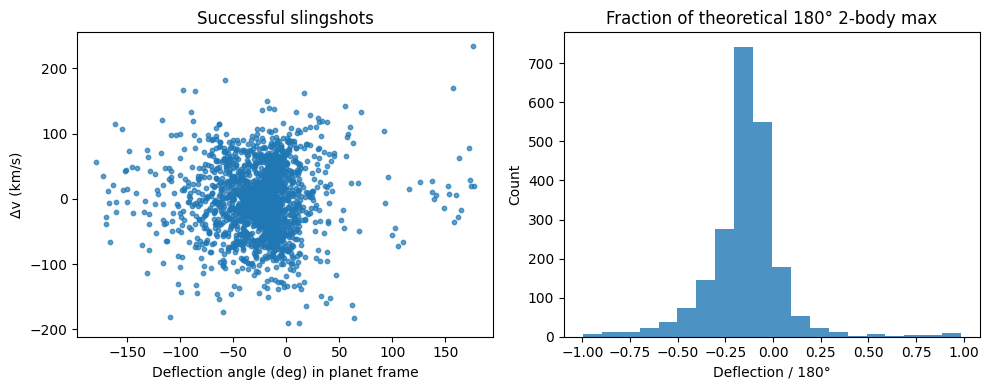


----------------------------------------------------------------------
BEST CANDIDATE (MC index #1090)
----------------------------------------------------------------------
Δv:               105.09 km/s
Deflection:         11.5°
r_min:           1954249 km
Unbound:            True
Frac(180°):        0.064
----------------------------------------------------------------------

Detailed trajectory plot:


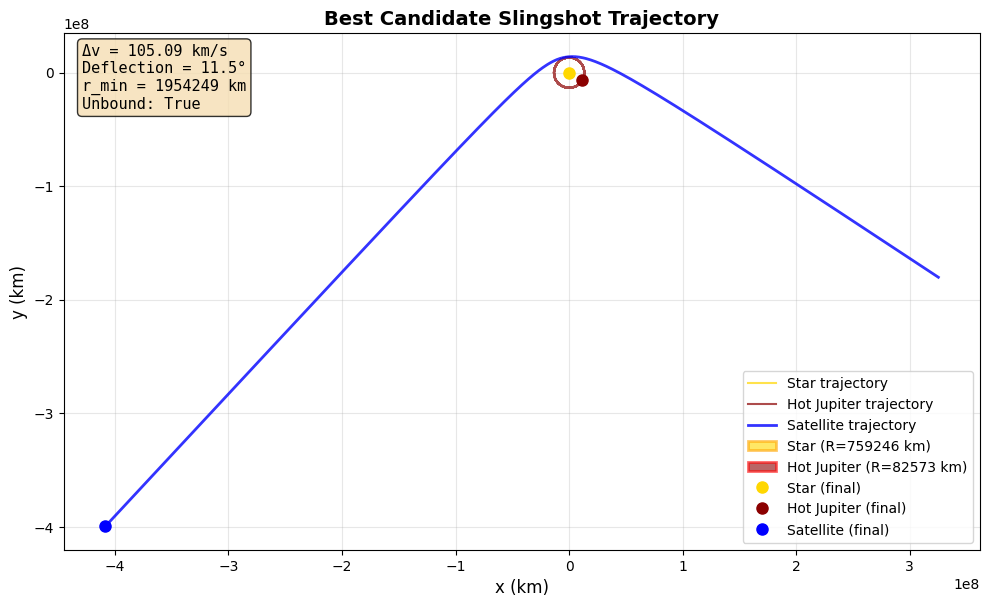

SIMULATION COMPLETE
Results stored in 'result' dict with keys:
  - mc:             Monte Carlo sweep results
  - top_indices:    Indices of top candidates
  - sols_top:       Best candidate trajectories
  - analyses_top:   Slingshot analysis for each candidate
  - Y0_top:         Initial conditions for best candidates


In [5]:
# ============================================================
# SIMULATION INTERFACE: USER-FACING CONFIGURATION
# ============================================================
# Modify parameters below to control the full pipeline and visualization

# Monte Carlo Phase: Initial sweep parameters
N_MC = 3000  # Number of test particles to sample
T_MC_MAX = 1e7  # Maximum simulation time (seconds)

# Re-run Phase: High-resolution follow-up
T_BEST_MAX = 1e7  # Maximum simulation time for best candidates (seconds)
N_EVAL_BEST = 1000  # Number of output points for best trajectories
TOP_FRAC = 0.10  # Fraction of successful cases to re-run (e.g., 0.10 = top 10%)
MIN_TOP = 1  # Minimum number of top candidates to keep

# --- Satellite sampling configuration ---
# Choose sampling mode: "planet" (orbit-relative) or "barycentric" (parametric hyperbolic)
SAMPLING_MODE = "barycentric"  # "planet" or "barycentric"

# Barycentric-unbound requirement for candidate selection. Options:
#   None    : don't require barycentric escape
#   'pre'   : require initial state to be unbound (eps_i_bary > 0)
#   'post'  : require final state to be unbound (eps_f_bary > 0)
#   'either': require pre OR post to be unbound
#   'both'  : require both pre AND post to be unbound
BARY_UNBOUND_REQUIREMENT = 'both'

# Selection metric: what to optimize when choosing top candidates
# Options:
#   'planet_delta_v'    : planet-frame Δv (existing default)
#   'bary_delta_v'      : barycentric Δv (v_f_bary - v_i_bary)
#   'bary_delta_v_pct'  : percent change 100*(v_f_bary - v_i_bary)/v_i_bary
#   'bary_delta_v_abs'  : absolute barycentric Δv (maximize magnitude)
SELECT_METRIC = 'bary_delta_v_pct'
# Selection sign: 'maximize' (largest positive), 'minimize' (smallest), or 'abs' (largest absolute)
SELECT_SIGN = 'maximize'

# PLANET-FRAME SAMPLING (relative to planet):
SAT_R_MIN_FACTOR_RUN = None   # e.g. 20 -> samples start radii >= 20 * R_planet
SAT_R_MAX_FACTOR_RUN = None   # e.g. 5 * (A_PLANET_KM / R_PLANET)
SAT_V_REL_MIN_RUN = None      # km/s, min relative velocity to planet
SAT_V_REL_MAX_RUN = None      # km/s, max relative velocity to planet

# BARYCENTRIC-FRAME SAMPLING (parametric hyperbolic encounters):
SAT_V_MAG_MIN_RUN = 10      # km/s, min asymptotic velocity magnitude
SAT_V_MAG_MAX_RUN = 120      # km/s, max asymptotic velocity magnitude
SAT_IMPACT_PARAM_MIN_RUN = A_PLANET_KM * 0.5   # km, min impact parameter
SAT_IMPACT_PARAM_MAX_RUN = A_PLANET_KM * 3 # km, max impact parameter
SAT_ANGLE_IN_MIN_RUN = -60.0  # deg, min incoming angle (deflection from purely radial)
SAT_ANGLE_IN_MAX_RUN = 60.0   # deg, max incoming angle

# ============================================================
# RUN THE FULL PIPELINE
# ============================================================

def run_full_pipeline_hot_jupiter(
    N_mc=N_MC,
    t_span_mc=(0.0, T_MC_MAX),
    t_span_best=(0.0, T_BEST_MAX),
    top_frac=TOP_FRAC,
    min_top=MIN_TOP,
    n_eval_best=N_EVAL_BEST,
    rng=None,
):
    """
    Complete slingshot analysis pipeline:
    1. Monte Carlo sweep of N_mc test particles
    2. Select the top fraction of successful cases by Δv
    3. Re-run those at higher resolution
    4. Produce summary plots and detailed visualization of the best candidate
    """
    if rng is None:
        rng = np.random.default_rng()

    print("=" * 70)
    print(f"SLINGSHOT DYNAMICS SIMULATOR: {SYSTEM_NAME}")
    print("=" * 70)
    print(f"Star mass: {M_STAR/M_SUN:.2f} M_sun")
    print(f"Planet mass: {M_PLANET/M_JUP:.1f} M_jup")
    print(f"Planet radius: {R_PLANET:.0f} km")
    print(f"Orbital semi-major axis: {A_PLANET_AU:.4f} AU ({A_PLANET_KM:.0f} km)")
    print()

    print("=" * 70)
    print("PHASE 1: MONTE CARLO SWEEP (FAST)")
    print("=" * 70)
    print(f"Sampling {N_mc} test particles ({SAMPLING_MODE} mode)...")
    print(f"Simulation timespan: {t_span_mc[0]:.0e} to {t_span_mc[1]:.0e} s")
    
    if SAMPLING_MODE == "barycentric":
        mc = run_batch_mc_3body_barycentric(
            N=N_mc,
            t_span=t_span_mc,
            v_mag_min=SAT_V_MAG_MIN_RUN,
            v_mag_max=SAT_V_MAG_MAX_RUN,
            impact_param_min=SAT_IMPACT_PARAM_MIN_RUN,
            impact_param_max=SAT_IMPACT_PARAM_MAX_RUN,
            angle_in_min=SAT_ANGLE_IN_MIN_RUN,
            angle_in_max=SAT_ANGLE_IN_MAX_RUN,
            bary_unbound_requirement=BARY_UNBOUND_REQUIREMENT,
        )
    else:
        mc = run_batch_mc_3body(
            N=N_mc,
            t_span=t_span_mc,
            r_min_factor=SAT_R_MIN_FACTOR_RUN,
            r_max_factor=SAT_R_MAX_FACTOR_RUN,
            v_rel_min=SAT_V_REL_MIN_RUN,
            v_rel_max=SAT_V_REL_MAX_RUN,
        )

    ok_count = mc["ok"].sum()
    success_rate = 100.0 * ok_count / N_mc
    print(f"✓ Successful slingshots: {ok_count}/{N_mc} ({success_rate:.1f}%)")
    print()

    print("=" * 70)
    print("PHASE 2: TOP CANDIDATE SELECTION")
    print("=" * 70)
    top_indices = select_top_indices_by_delta_v_with_bary(
        mc,
        top_frac=top_frac,
        min_top=min_top,
        bary_unbound_requirement=BARY_UNBOUND_REQUIREMENT,
        metric=SELECT_METRIC,
        sign=SELECT_SIGN,
    )
    print(f"Selecting top {len(top_indices)} candidates (top {top_frac*100:.0f}% by Δv)")
    print(f"Selected indices: {top_indices}")
    print()

    if top_indices.size == 0:
        print("✗ No good slingshots found. Exiting.")
        return {
            "mc": mc,
            "top_indices": top_indices,
            "sols_top": [],
            "analyses_top": [],
        }

    print("=" * 70)
    print("PHASE 3: HIGH-RESOLUTION RE-RUN")
    print("=" * 70)
    print(f"Re-running top {len(top_indices)} candidates at high resolution...")
    print(f"Simulation timespan: {t_span_best[0]:.0e} to {t_span_best[1]:.0e} s")
    print(f"Output points per trajectory: {n_eval_best}")
    
    sols_top, analyses_top, Y0_top = rerun_top_candidates_3body(
        mc,
        top_indices,
        t_span=t_span_best,
        n_eval=n_eval_best,
    )
    print("✓ Re-run complete")
    print()

    print("=" * 70)
    print("PHASE 4: VISUALIZATION AND ANALYSIS")
    print("=" * 70)
    print("Monte Carlo summary plots:")
    plot_mc_summary(mc)
    
    # Find and plot the BEST candidate (highest Δv among successful ones)
    valid_indices = [i for i, (sol, ana) in enumerate(zip(sols_top, analyses_top)) 
                     if sol is not None and ana is not None]
    
    if valid_indices:
        best_local_idx = max(valid_indices, 
                             key=lambda i: analyses_top[i]["delta_v"])
        best_sol = sols_top[best_local_idx]
        best_analysis = analyses_top[best_local_idx]
        best_original_idx = top_indices[best_local_idx]
        
        print()
        print("-" * 70)
        print(f"BEST CANDIDATE (MC index #{best_original_idx})")
        print("-" * 70)
        print(f"Δv:         {best_analysis['delta_v']:>12.2f} km/s")
        print(f"Deflection: {best_analysis['deflection']:>12.1f}°")
        print(f"r_min:      {best_analysis['r_min']:>12.0f} km")
        print(f"Unbound:    {str(best_analysis['unbound_f']):>12s}")
        print(f"Frac(180°): {best_analysis['frac_of_180']:>12.3f}")
        print("-" * 70)
        print()
        print("Detailed trajectory plot:")
        plot_best_candidate_with_bodies(best_sol, best_analysis)
    else:
        print("✗ No valid trajectories found in re-run.")

    return {
        "mc": mc,
        "top_indices": top_indices,
        "sols_top": sols_top,
        "analyses_top": analyses_top,
        "Y0_top": Y0_top,
    }

# ============================================================
# EXECUTE THE PIPELINE
# ============================================================

result = run_full_pipeline_hot_jupiter(
    N_mc=N_MC,
    t_span_mc=(0.0, T_MC_MAX),
    t_span_best=(0.0, T_BEST_MAX),
    top_frac=TOP_FRAC,
    min_top=MIN_TOP,
    n_eval_best=N_EVAL_BEST,
)

print("=" * 70)
print("SIMULATION COMPLETE")
print("=" * 70)
print(f"Results stored in 'result' dict with keys:")
print(f"  - mc:             Monte Carlo sweep results")
print(f"  - top_indices:    Indices of top candidates")
print(f"  - sols_top:       Best candidate trajectories")
print(f"  - analyses_top:   Slingshot analysis for each candidate")
print(f"  - Y0_top:         Initial conditions for best candidates")



=== Phase-Space & Summary (Best candidate) ===\n
Best re-run local index: 141 (original MC idx: 1090)
Initial speed (barycentric) : 82.491 km/s
Final speed   (barycentric) : 91.194 km/s
Δv (final - initial)       : 8.704 km/s (+10.55 % change)
Planet-frame Δv             : 105.086 km/s
Planet-frame eps_f         : 1.967e+04 km^2/s^2


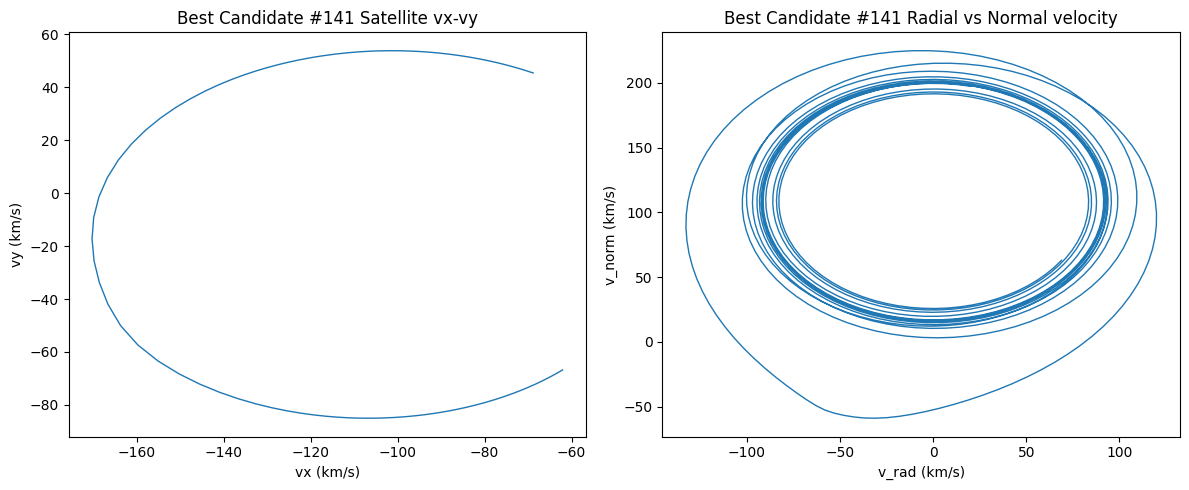


=== Monte Carlo aggregate ===
Total samples: 3000
Successful (planet-frame): 2171
Barycentric unbound (final): 2171
Barycentric unbound (initial): 2171


In [12]:
# Phase-space plots and summary statistics (velocity components)
import numpy as np
import matplotlib.pyplot as plt

# Expect `result` to exist from the pipeline run
mc = result.get('mc', None) if isinstance(result, dict) else None
sols_top = result.get('sols_top', None) if isinstance(result, dict) else None
analyses_top = result.get('analyses_top', None) if isinstance(result, dict) else None

def plot_velocity_phase_space(sol, title_prefix=''):
    if sol is None:
        print('No solution to plot.')
        return
    y = sol.y
    vx = y[10]
    vy = y[11]
    # radial and normal velocities relative to planet
    xs = y[0]
    ys = y[1]
    xp = y[4]
    yp = y[5]
    dx = xs - xp
    dy = ys - yp
    r = np.hypot(dx, dy)
    # unit radial from planet to satellite
    erx = dx / r
    ery = dy / r
    # unit normal (90 deg CCW)
    enx = -ery
    eny = erx

    # compute velocities of satellite relative to planet
    vxsat = vx
    vysat = vy
    vxp = y[6]
    vyp = y[7]
    dvx = vxsat - vxp
    dvy = vysat - vyp

    v_rad = dvx * erx + dvy * ery
    v_norm = dvx * enx + dvy * eny

    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    axes[0].plot(vx, vy, lw=1)
    axes[0].set_xlabel('vx (km/s)')
    axes[0].set_ylabel('vy (km/s)')
    axes[0].set_title(f'{title_prefix} Satellite vx-vy')

    axes[1].plot(v_rad, v_norm, lw=1)
    axes[1].set_xlabel('v_rad (km/s)')
    axes[1].set_ylabel('v_norm (km/s)')
    axes[1].set_title(f'{title_prefix} Radial vs Normal velocity')

    plt.tight_layout()
    plt.show()

def summary_statistics_for_sol(sol, analysis=None):
    if sol is None:
        return 'No solution.'
    y = sol.y
    # initial and final planet-frame speeds
    # choose far indices if available, else endpoints
    vx = y[10]
    vy = y[11]
    v_total = np.hypot(vx, vy)
    v_i = v_total[0]
    v_f = v_total[-1]
    delta_v = v_f - v_i
    delta_v_pct = 100.0 * delta_v / v_i if v_i != 0 else np.nan

    lines = []
    lines.append(f'Initial speed (barycentric) : {v_i:.3f} km/s')
    lines.append(f'Final speed   (barycentric) : {v_f:.3f} km/s')
    lines.append(f'Δv (final - initial)       : {delta_v:.3f} km/s ({delta_v_pct:+.2f} % change)')
    if analysis is not None:
        # include planet-frame Δv if available
        if 'delta_v' in analysis:
            lines.append(f"Planet-frame Δv             : {analysis['delta_v']:.3f} km/s")
        if 'eps_f' in analysis:
            lines.append(f"Planet-frame eps_f         : {analysis['eps_f']:.3e} km^2/s^2")
        if 'eps_f_bary' in analysis:
            lines.append(f"Barycentric eps_f          : {analysis['eps_f_bary']:.3e} km^2/s^2")
    return '\n'.join(lines)

print('\n=== Phase-Space & Summary (Best candidate) ===\\n')
# Determine best candidate among re-run trajectories by planet-frame Δv
best_local_idx = None
if sols_top is None or len(sols_top) == 0:
    print('No high-resolution candidate trajectories available.')
else:
    valid_indices = [i for i, (sol, ana) in enumerate(zip(sols_top, analyses_top)) if sol is not None and ana is not None]
    if not valid_indices:
        print('No valid re-run trajectories (sols_top/analyses_top contain no usable data).')
    else:
        # Choose best by planet-frame delta_v if present, otherwise barycentric delta_v
        def get_score(i):
            ana = analyses_top[i]
            if ana is None:
                return -np.inf
            # prefer planet-frame delta_v if available
            if 'delta_v' in ana and ana['delta_v'] is not None:
                return ana['delta_v']
            # fallback to barycentric delta_v
            if 'delta_v_bary' in ana and ana['delta_v_bary'] is not None:
                return ana['delta_v_bary']
            return -np.inf

        best_local_idx = max(valid_indices, key=get_score)
        best_sol = sols_top[best_local_idx]
        best_ana = analyses_top[best_local_idx]
        try:
            orig_idx = result.get('top_indices')[best_local_idx]
        except Exception:
            orig_idx = 'N/A'
        print(f'Best re-run local index: {best_local_idx} (original MC idx: {orig_idx})')
        print(summary_statistics_for_sol(best_sol, best_ana))
        plot_velocity_phase_space(best_sol, title_prefix=f'Best Candidate #{best_local_idx}')

# Also provide MC-level aggregated stats
if mc is not None:
    ok = mc['ok']
    print('\n=== Monte Carlo aggregate ===')
    print(f"Total samples: {len(ok)}")
    print(f"Successful (planet-frame): {ok.sum()}")
    if 'unbound_bary' in mc:
        print(f"Barycentric unbound (final): {mc['unbound_bary'].sum()}")
    if 'unbound_i_bary' in mc:
        print(f"Barycentric unbound (initial): {mc['unbound_i_bary'].sum()}")


In [89]:
def extract_encounter_states(
    sol,
    m_p,
    R_p,
    r_far_factor=8.0,
    min_clearance_factor=1.05,
):
    """
    From a restricted 3-body solution (barycentric frame), extract:

    - indices for "far in", periapsis, and "far out"
    - planet-frame and barycentric states at those points

    Returns dict with keys:
      i0, i1, k_min
      r_rel_i, v_rel_i   (planet frame, incoming)
      r_rel_f, v_rel_f   (planet frame, outgoing)
      r_rel_p, v_rel_p   (planet frame, periapsis)
      r_in_bary, v_in_bary
      r_out_bary, v_out_bary
      r_min, ok_geometry (bool)
    """

    if sol is None or sol.y.shape[1] < 3:
        return None

    y = sol.y
    t = sol.t

    # unpack
    xp, yp = y[4], y[5]
    vxp, vyp = y[6], y[7]
    xsat, ysat = y[8], y[9]
    vxsat, vysat = y[10], y[11]

    # planet-frame position of satellite
    dx = xsat - xp
    dy = ysat - yp
    r = np.hypot(dx, dy)

    # periapsis = min distance to planet
    k_min = int(np.argmin(r))
    r_min = float(r[k_min])

    # reject if it gets too close to the physical planet
    if r_min <= R_p * min_clearance_factor:
        return {
            "ok_geometry": False,
            "reason": "collision_or_graze",
            "r_min": r_min,
        }

    # choose "far" indices: r > r_far
    r_far = R_p * r_far_factor
    far_idx = np.where(r > r_far)[0]
    if far_idx.size < 2:
        return {
            "ok_geometry": False,
            "reason": "never_far_in_out",
            "r_min": r_min,
        }

    i0 = int(far_idx[0])
    i1 = int(far_idx[-1])

    # planet-frame velocities
    dvx = vxsat - vxp
    dvy = vysat - vyp

    r_rel_i = np.array([dx[i0], dy[i0]])
    v_rel_i = np.array([dvx[i0], dvy[i0]])
    r_rel_f = np.array([dx[i1], dy[i1]])
    v_rel_f = np.array([dvx[i1], dvy[i1]])
    r_rel_p = np.array([dx[k_min], dy[k_min]])
    v_rel_p = np.array([dvx[k_min], dvy[k_min]])

    # barycentric satellite states at in/out
    r_in_bary  = np.array([xsat[i0], ysat[i0]])
    v_in_bary  = np.array([vxsat[i0], vysat[i0]])
    r_out_bary = np.array([xsat[i1], ysat[i1]])
    v_out_bary = np.array([vxsat[i1], vysat[i1]])

    return {
        "ok_geometry": True,
        "i0": i0,
        "i1": i1,
        "k_min": k_min,
        "r_rel_i": r_rel_i,
        "v_rel_i": v_rel_i,
        "r_rel_f": r_rel_f,
        "v_rel_f": v_rel_f,
        "r_rel_p": r_rel_p,
        "v_rel_p": v_rel_p,
        "r_in_bary": r_in_bary,
        "v_in_bary": v_in_bary,
        "r_out_bary": r_out_bary,
        "v_out_bary": v_out_bary,
        "r_min": r_min,
        "t_in": float(t[i0]),
        "t_out": float(t[i1]),
    }


In [104]:
def two_body_hyperbola_from_state(r_vec, v_vec, mu):
    """
    Given planet-centric position and velocity (km, km/s) and mu = G*M_p,
    compute hyperbolic orbital parameters for the equivalent 2-body flyby.

    Returns dict with:
      a, e, eps, v_inf, delta_2body, r_p, h, hyperbolic (bool)
    """
    r = np.linalg.norm(r_vec)
    v = np.linalg.norm(v_vec)

    # specific angular momentum (3D)
    h_vec = np.cross([r_vec[0], r_vec[1], 0.0],
                     [v_vec[0], v_vec[1], 0.0])
    h = np.linalg.norm(h_vec)

    # specific energy
    eps = 0.5 * v * v - mu / r

    if eps <= 0:
        # not actually unbound in the pure 2-body sense
        return {
            "hyperbolic": False,
            "eps": eps,
            "a": None,
            "e": None,
            "v_inf": None,
            "delta_2body": None,
            "r_p": None,
            "h": h,
        }

    # hyperbolic elements
    a = -mu / (2.0 * eps)  # a < 0
    e = np.sqrt(1.0 + 2.0 * eps * h * h / mu**2)
    v_inf = np.sqrt(2.0 * eps)

    # turning angle (radians): δ = 2 * arcsin(1/e)
    delta_2body = 2.0 * np.degrees(np.arcsin(1.0 / e))

    # periapsis distance r_p = a (e^2 - 1) / (1 + e)
    # or more simply r_p = h^2 / (mu * (1 + e))
    r_p = h * h / (mu * (1.0 + e))

    return {
        "hyperbolic": True,
        "a": a,
        "e": e,
        "eps": eps,
        "v_inf": v_inf,
        "delta_2body": delta_2body,
        "r_p": r_p,
        "h": h,
    }

def sample_hyperbola_orbit(two_body, n_pts=2000, r_factor=1, r_max=None):
    """
    Sample only the near-periapsis part of the 2-body hyperbola.

    Parameters
    ----------
    two_body : dict
        Output of two_body_hyperbola_from_state, must contain 'a', 'e', 'r_p'.
    n_pts : int
        Number of sample points along the orbit before trimming.
    r_factor : float
        If r_max is None, keep r <= r_factor * r_p (MUST be > 1).
    r_max : float or None
        Absolute max radius (km). If given, overrides r_factor.

    Returns
    -------
    x_pf, y_pf : arrays
        Hyperbola coordinates in periapsis frame, truncated near periapsis.
    r_cut : float
        Radius cutoff actually used (km).
    """
    a = two_body["a"]
    e = two_body["e"]
    r_p = two_body["r_p"]

    # true anomaly at asymptote: cos f_inf = -1/e
    f_inf = np.arccos(-1.0 / e)
    # avoid exact asymptote where r -> ±∞
    f_max = 0.99 * f_inf
    f = np.linspace(-f_max, f_max, n_pts)

    # hyperbolic r(f)
    r = a * (e*e - 1.0) / (1.0 + e * np.cos(f))
    r = np.abs(r)  # enforce positive radius

    # choose radius cutoff
    if r_max is None:
        if r_factor <= 1.0:
            raise ValueError(f"r_factor must be > 1, got {r_factor}")
        r_cut = r_factor * r_p
    else:
        r_cut = r_max

    # keep only near-periapsis part: r <= r_cut
    mask = r <= r_cut
    if not np.any(mask):
        # nothing within r_cut; just keep everything as fallback
        r_trim = r
        f_trim = f
    else:
        r_trim = r[mask]
        f_trim = f[mask]

    x_pf = r_trim * np.cos(f_trim)
    y_pf = r_trim * np.sin(f_trim)

    return x_pf, y_pf, r_cut

def hyperbola_to_planet_frame(two_body, enc, x_pf, y_pf):
    """
    Rotate & place the sampled hyperbola so that:
      - periapsis direction matches the 3-body periapsis r_rel_p
      - tangential direction matches 3-body v_rel_p

    enc: encounter dict from extract_encounter_states()
    Returns (x, y) in planet frame.
    """
    r_p_vec = enc["r_rel_p"]
    v_p_vec = enc["v_rel_p"]

    r_p_hat = r_p_vec / np.linalg.norm(r_p_vec)
    v_p_hat = v_p_vec / np.linalg.norm(v_p_vec)

    # rotation matrix from periapsis frame (x_pf,y_pf) -> planet frame
    R = np.column_stack([r_p_hat, v_p_hat])  # 2x2

    pos_pf = np.vstack([x_pf, y_pf])  # 2 x N
    pos_planet_frame = R @ pos_pf

    return pos_planet_frame[0], pos_planet_frame[1]

In [91]:
from scipy.integrate import solve_ivp

def monopole_ode(t, Y, M_tot):
    x, y, vx, vy = Y
    r2 = x*x + y*y
    r = np.sqrt(r2)
    r3 = r2 * r
    ax = -G * M_tot * x / r3
    ay = -G * M_tot * y / r3
    return [vx, vy, ax, ay]

def simulate_monopole_baseline(r_in, v_in, t_in, t_out, M_tot):
    """
    Integrate a baseline 2-body problem with mass M_tot at origin,
    starting from (r_in, v_in) at "time" 0, for duration Δt = t_out - t_in.

    Returns sol, and (r_out, v_out).
    """
    dt = t_out - t_in
    Y0 = np.array([r_in[0], r_in[1], v_in[0], v_in[1]], dtype=float)

    sol = solve_ivp(
        monopole_ode,
        (0.0, dt),
        Y0,
        args=(M_tot,),
        rtol=RTOL,
        atol=ATOL,
        dense_output=False,
    )

    if not sol.success:
        print("Monopole integration failed:", sol.message)
        return None, None, None

    x_end, y_end, vx_end, vy_end = sol.y[:, -1]
    r_out = np.array([x_end, y_end])
    v_out = np.array([vx_end, vy_end])

    return sol, r_out, v_out

def energy_and_angmom(r, v, M_tot):
    """
    Specific orbital energy and angular momentum wrt origin (barycenter).
    """
    r_mag = np.linalg.norm(r)
    v_mag = np.linalg.norm(v)
    eps = 0.5 * v_mag*v_mag - G*M_tot / r_mag

    h_vec = np.cross([r[0], r[1], 0.0], [v[0], v[1], 0.0])
    h = np.linalg.norm(h_vec)

    return eps, h


In [108]:
def compare_3body_with_baselines(
    sol,
    m_star=M_STAR,
    m_p=M_PLANET,
    R_p=R_JUP,
    r_far_factor=8.0,
    min_clearance_factor=1.05,
    n_pts_hyp=1000,
    make_plots=True,
):
    """
    For a given 3-body trajectory sol (best candidate), do:

      1. Extract encounter geometry (planet frame & barycentric)
      2. Build equivalent 2-body hyperbola (planet only)
      3. Integrate monopole baseline (M_tot at barycenter)
      4. Compute energies and angular momenta
      5. Optionally make comparison plots

    Returns a dict of all comparison numbers.
    """

    M_tot = m_star + m_p
    mu_p = G * m_p

    # --- 1. Extract encounter ---
    enc = extract_encounter_states(
        sol,
        m_p=m_p,
        R_p=R_p,
        r_far_factor=r_far_factor,
        min_clearance_factor=min_clearance_factor,
    )
    if enc is None or not enc.get("ok_geometry", False):
        print("Encounter not suitable:", enc)
        return None

    r_rel_i = enc["r_rel_i"]
    v_rel_i = enc["v_rel_i"]
    r_rel_f = enc["r_rel_f"]
    v_rel_f = enc["v_rel_f"]
    r_in_bary = enc["r_in_bary"]
    v_in_bary = enc["v_in_bary"]
    r_out_bary_3b = enc["r_out_bary"]
    v_out_bary_3b = enc["v_out_bary"]

    # --- 2. Planet-only 2-body hyperbola ---
    two_body = two_body_hyperbola_from_state(r_rel_i, v_rel_i, mu_p)

    if not two_body["hyperbolic"]:
        print("Incoming state is not hyperbolic in pure 2-body sense.")
    else:
        v_inf = two_body["v_inf"]
        delta_2body = two_body["delta_2body"]

        # actual 3-body deflection (planet frame)
        vi_hat = v_rel_i / np.linalg.norm(v_rel_i)
        vf_hat = v_rel_f / np.linalg.norm(v_rel_f)
        cos_defl = np.clip(np.dot(vi_hat, vf_hat), -1.0, 1.0)
        delta_3body = np.degrees(np.arccos(cos_defl))

        def rotate2d(v, angle_deg):
            a = np.radians(angle_deg)
            c, s = np.cos(a), np.sin(a)
            x, y = v
            return np.array([c*x - s*y, s*x + c*y])

        v_out_2body_vec = rotate2d(vi_hat, delta_2body) * v_inf

        angle_between_out = np.degrees(
            np.arccos(
                np.clip(
                    np.dot(v_out_2body_vec, v_rel_f)
                    / (np.linalg.norm(v_out_2body_vec)*np.linalg.norm(v_rel_f)),
                    -1.0, 1.0
                )
            )
        )
        dv_mag_diff_planet = np.linalg.norm(v_rel_f) - np.linalg.norm(v_out_2body_vec)

    # --- 3. Barycentric monopole baseline ---
    sol_mono, r_out_bary_0, v_out_bary_0 = simulate_monopole_baseline(
        r_in_bary, v_in_bary, enc["t_in"], enc["t_out"], M_tot
    )
    if sol_mono is None:
        print("Monopole baseline integration failed.")
        return None

    # energies and angular momenta wrt barycenter
    eps_in, h_in = energy_and_angmom(r_in_bary, v_in_bary, M_tot)
    eps_3b, h_3b = energy_and_angmom(r_out_bary_3b, v_out_bary_3b, M_tot)
    eps_0,  h_0  = energy_and_angmom(r_out_bary_0,  v_out_bary_0,  M_tot)

    delta_eps_3b = eps_3b - eps_in
    delta_eps_0  = eps_0  - eps_in
    extra_eps_from_planet = eps_3b - eps_0

    delta_h_3b = h_3b - h_in
    delta_h_0  = h_0  - h_in
    extra_h_from_planet = h_3b - h_0

    # --- 4. Plots ---
    if make_plots:
        # (a) Planet-frame trajectory vs 2-body hyperbola
        if two_body["hyperbolic"]:
            x_pf, y_pf, r_cut = sample_hyperbola_orbit(
                two_body,
                n_pts=n_pts_hyp,
                r_factor=5.0,
                r_max=None,
            )
            x_hyp, y_hyp = hyperbola_to_planet_frame(two_body, enc, x_pf, y_pf)

            # full 3-body solution
            y_all = sol.y
            xp, yp = y_all[4], y_all[5]
            xsat, ysat = y_all[8], y_all[9]

            # planet-frame relative position
            dx = xsat - xp
            dy = ysat - yp
            r_rel = np.sqrt(dx**2 + dy**2)

            # trim 3-body curve to same radius window
            mask3 = r_rel <= r_cut
            x3_pf = dx[mask3]
            y3_pf = dy[mask3]

            plt.figure(figsize=(10, 6))
            # planet at origin in planet frame
            plt.scatter(
                0.0, 0.0,
                s=60,
                marker="o",
                edgecolor="k",
                facecolor="k",
                label=f"Planet ({SYSTEM_NAME} b)"
            )
            plt.plot(x_hyp, y_hyp, label="Analytic 2-body hyperbola")
            plt.plot(x3_pf, y3_pf, label="Numerical 3-body (planet frame)", alpha=0.8)

            ax = plt.gca()
            ax.set_aspect("equal", "box")
            plt.xlabel("x (km) in planet frame")
            plt.ylabel("y (km) in planet frame")
            plt.title(f"{SYSTEM_NAME} – Planet-frame slingshot comparison")

            margin = 0.5
            plt.xlim(-margin * r_cut, margin * r_cut)
            plt.ylim(-margin * r_cut, margin * r_cut)

            plt.legend()
            plt.tight_layout()
            plt.show()

        # (b) Barycentric comparison: 3-body vs monopole
        xsat = sol.y[8]
        ysat = sol.y[9]
        x_star = sol.y[0]
        y_star = sol.y[1]

        plt.figure(figsize=(10, 6))
        # barycenter / monopole location at origin
        plt.scatter(
            0.0, 0.0,
            s=70,
            marker="+",
            color="k",
            label="Barycenter / M_tot"
        )
        # actual star trajectory (optional but nice)
        plt.plot(x_star, y_star, color="orange", linewidth=1.0, label="Star trajectory")

        plt.plot(xsat, ysat, label="3-body satellite trajectory")
        plt.plot(sol_mono.y[0], sol_mono.y[1], "--", label="Monopole baseline")

        ax = plt.gca()
        ax.set_aspect("equal", "box")
        plt.xlabel("x (km) barycentric")
        plt.ylabel("y (km) barycentric")
        plt.title(f"{SYSTEM_NAME} – Barycentric comparison: 3-body vs M_tot monopole")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # --- 5. Collect results ---
    out = {
        "encounter": enc,
        "two_body": two_body,
        "bary_eps_in": eps_in,
        "bary_eps_3b": eps_3b,
        "bary_eps_0": eps_0,
        "bary_h_in": h_in,
        "bary_h_3b": h_3b,
        "bary_h_0": h_0,
        "delta_eps_3b": delta_eps_3b,
        "delta_eps_0": delta_eps_0,
        "extra_eps_from_planet": extra_eps_from_planet,
        "delta_h_3b": delta_h_3b,
        "delta_h_0": delta_h_0,
        "extra_h_from_planet": extra_h_from_planet,
    }

    if two_body["hyperbolic"]:
        out.update({
            "delta_2body": delta_2body,
            "delta_3body": delta_3body,
            "angle_between_out": angle_between_out,
            "dv_mag_diff_planet": dv_mag_diff_planet,
        })

    return out

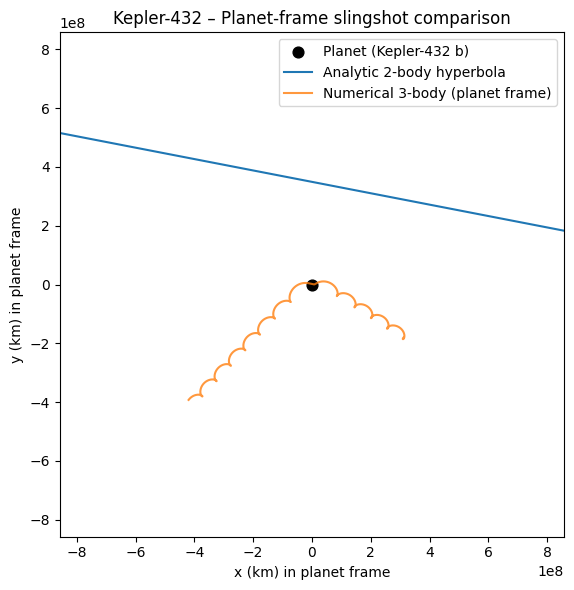

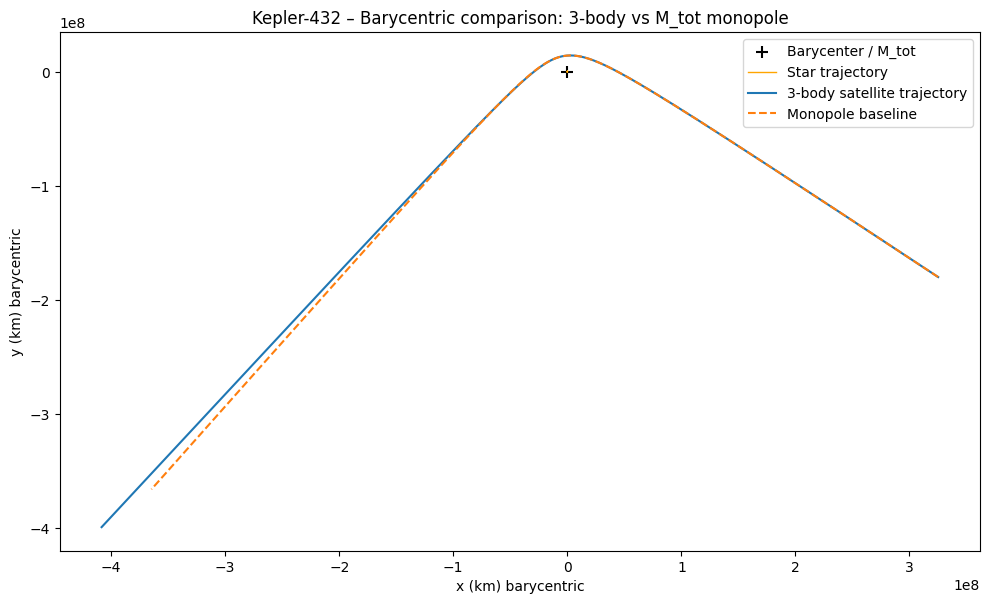


=== Planet-frame comparison ===
2-body deflection (planet frame)     : 0.02528673671205627 deg
3-body deflection (planet frame)     : 11.455719110443411 deg
Angle between v_out(2b) and v_out(3b): 11.43043237373138 deg
Δ|v_out| (3b - 2b, planet frame)     : 105.10570007764413 km/s

=== Barycentric energy & AM ===
Δeps_3b (actual)     : 904.8313768818584 km^2/s^2
Δeps_0 (monopole)    : -4.2651572584873065e-07 km^2/s^2
Extra eps from planet: 904.8313773083742 km^2/s^2
Δh_3b (actual)       : 111501046.44406891 km^2/s
Δh_0 (monopole)      : 0.049457550048828125 km^2/s
Extra h from planet  : 111501046.39461136 km^2/s


In [109]:
# Example: if you stored your best solution as best_sol
comparison = compare_3body_with_baselines(
    best_sol,
    m_star=M_STAR,
    m_p=M_PLANET,
    R_p=R_JUP,
    make_plots=True,
)

print("\n=== Planet-frame comparison ===")
if comparison["two_body"]["hyperbolic"]:
    print("2-body deflection (planet frame)     :", comparison["delta_2body"], "deg")
    print("3-body deflection (planet frame)     :", comparison["delta_3body"], "deg")
    print("Angle between v_out(2b) and v_out(3b):",
          comparison["angle_between_out"], "deg")
    print("Δ|v_out| (3b - 2b, planet frame)     :",
          comparison["dv_mag_diff_planet"], "km/s")

print("\n=== Barycentric energy & AM ===")
print("Δeps_3b (actual)     :", comparison["delta_eps_3b"], "km^2/s^2")
print("Δeps_0 (monopole)    :", comparison["delta_eps_0"], "km^2/s^2")
print("Extra eps from planet:", comparison["extra_eps_from_planet"], "km^2/s^2")
print("Δh_3b (actual)       :", comparison["delta_h_3b"], "km^2/s")
print("Δh_0 (monopole)      :", comparison["delta_h_0"], "km^2/s")
print("Extra h from planet  :", comparison["extra_h_from_planet"], "km^2/s")
